In [1]:
import xarray as xr
import pandas as pd
import geopandas
import datetime
import matplotlib.pyplot as plt
from functions import getDayMeans, AddDateColumn, getMonthMeans, getReferenceDateDay
import numpy as np  

In [2]:

from scipy.signal import savgol_filter

#function for running mean over the time series
def running_mean(x, N):
    """Compute the centered running mean of a 1D array.

    Parameters:
    x (array-like): Input 1D array.
    N (int): Window size for the running mean (centered around each point).

    Returns:
    array-like: Array of the same length as x containing the centered running mean.
    """
    return pd.Series(x).rolling(window=N, center=True, min_periods=1).mean().values

def AddRunningMeanColumn(df, N, var):
    """Add a centered running mean column to a DataFrame.

    Parameters:
    df (pd.DataFrame): Input DataFrame with a column specified by `var`.
    N (int): Window size for the running mean (centered around each point).

    Returns:
    pd.DataFrame: DataFrame with an additional running mean column for the specified variable.
    """
    df[f'{var}_{N}RunningMean'] = df[var].rolling(window=N, center=True, min_periods=1).mean().values
    return df

def AddRunningMeanColumnDate(df, N, var):
    """Add a date-based centered rolling mean column to a DataFrame.

    Unlike AddRunningMeanColumn (which rolls over N consecutive data points),
    this function uses a window of N calendar days centered on each date.
    Missing days are treated as NaN, so gaps in the data don't shift or
    shrink the window.

    Parameters:
    df (pd.DataFrame): Input DataFrame with 'Date' and `var` columns.
    N (int): Window size in calendar days (centered around each date).
    var (str): Name of the column to smooth.

    Returns:
    pd.DataFrame: DataFrame with an additional column '{var}_{N}dRunningMean'.
    """
    date_range = pd.date_range(df['Date'].min(), df['Date'].max(), freq='D')
    # Reindex onto a complete daily grid so every calendar day is present
    s = df.set_index('Date')[var].reindex(date_range)
    # Count-based rolling on the complete grid == date-based rolling
    rolled = s.rolling(window=N, center=True, min_periods=1).mean()
    df[f'{var}_{N}dRunningMean'] = df['Date'].map(rolled).values
    return df

def AddGaussSmoothedColumn(df, N, var, std=None):
    """Add a Gaussian-weighted date-based smoothed column.

    Uses a Gaussian kernel over N calendar days. Points closer to
    the center date get exponentially more weight than points at
    the edge. Produces smoother curves than a uniform rolling mean.

    Parameters:
    df (pd.DataFrame): Input DataFrame with 'Date' and `var` columns.
    N (int): Window size in calendar days (must be odd).
    var (str): Column name to smooth.
    std (float): Standard deviation of the Gaussian kernel in days.
                 Default: N/4 (~95% of weight within the window).

    Returns:
    pd.DataFrame: DataFrame with column '{var}_{N}dGauss'.
    """
    if N % 2 == 0:
        N += 1  # Gaussian window must be odd
    if std is None:
        std = N / 4
    date_range = pd.date_range(df['Date'].min(), df['Date'].max(), freq='D')
    s = df.set_index('Date')[var].reindex(date_range)
    rolled = s.rolling(window=N, center=True, min_periods=1,
                       win_type='gaussian').mean(std=std)
    df[f'{var}_{N}dGauss'] = df['Date'].map(rolled).values
    return df

def AddSavGolSmoothedColumn(df, N, var, polyorder=2):
    """Add a Savitzky-Golay filtered date-based smoothed column.

    Fits a local polynomial of degree `polyorder` over N calendar days.
    Preserves peaks/valleys much better than a moving average — standard
    in remote sensing for vegetation index smoothing (e.g. TIMESAT).
    Handles NaN gaps by reindexing to a daily grid, interpolating for
    the filter, then masking back to NaN where no data existed.

    Parameters:
    df (pd.DataFrame): Input DataFrame with 'Date' and `var` columns.
    N (int): Window size in calendar days (must be odd, > polyorder).
    var (str): Column name to smooth.
    polyorder (int): Polynomial order (default 2 = quadratic).

    Returns:
    pd.DataFrame: DataFrame with column '{var}_{N}dSavGol'.
    """
    if N % 2 == 0:
        N += 1
    date_range = pd.date_range(df['Date'].min(), df['Date'].max(), freq='D')
    s = df.set_index('Date')[var].reindex(date_range)
    mask = s.isna()
    # Interpolate gaps so savgol_filter can run on a continuous array
    s_filled = s.interpolate(method='linear', limit_direction='both')
    smoothed = pd.Series(savgol_filter(s_filled.values, N, polyorder),
                         index=date_range)
    smoothed[mask] = np.nan  # restore NaN where original data was missing
    df[f'{var}_{N}dSavGol'] = df['Date'].map(smoothed).values
    return df

def MSC(df, var):
    """Mean Seasonal Cycle (MSC) calculation.

    Parameters:
    df (pd.DataFrame): Input DataFrame with 'Month', 'Day', and the specified `var` columns.

    Returns:
    pd.DataFrame: DataFrame containing the mean seasonal cycle.
    """
    msc = df.groupby(['Month','Day'])[var].mean().reset_index()
    msc.rename(columns={var: f'MSC_{var}'}, inplace=True)
    df_ = df.merge(msc, on=['Month','Day'], how='left')
    return df_


In [3]:
Selection_region = ["Hudson_Valley_2023", "Hudson_Valley_2024", "Virginia_2024", "Pennsylvania2_2023", "New_Hampshire_2022", 
                    "Lake_George_2022", "Lake_Champlain_2022", "Southern_Tier_2022", "Michigan2_2022", "Wisconsin_Michigan_2022", 
                    "Wisconsin1_2022", "Michigan2_2021", "Michigan3_2021", "Adirondacks1_2021", "Adirondacks2_2021", 
                    "New_Hampshire_Maine_2021", "Finger_Lakes_2021", "Allegheny_Reservoir_2021", "Michigan3_2020"]

RegionName = Selection_region[5]
startyear = 2019
endyear = 2025
defolyear = 2024
Number = "US"

In [4]:
Regions = pd.read_pickle(f"/kiwi-data/Data/groupMembers/evametz/SIF_defoliage/data/US_regions/OutbreakMasks/{RegionName}_polygon.pkl")


In [5]:
df01 = pd.read_pickle(f'/kiwi-data/Data/groupMembers/evametz/SIF_defoliage/data/DataFrames/SingleObs_Poly_TROPOMISIF743daily_743ErrorSmaller10_SIFin-2to5_{RegionName}_{Number}_{startyear}_{endyear}_WTOA_new.pkl')


In [6]:
df01 = df01.to_crs("epsg:4326")
Regions = Regions.to_crs("epsg:4326")


In [7]:
df01.insert(0, "SIF_Corr_743_TOAnorm" , df01["SIF_Corr_743"] / df01["Mean_TOA_RAD_743"])

In [8]:
#get daily means and add date column
df01['Area'] = df01['Overlap_Area_cea']

df01 = AddDateColumn(df01)

df1nWTOA = getDayMeans(df01, 2019, 1, 1, 2025, 12, 31, ValueName='SIF_Corr_743_TOAnorm', weighting='none')
df1aWTOA = getDayMeans(df01, 2019, 1, 1, 2025, 12, 31, ValueName='SIF_Corr_743_TOAnorm', Error_name='SIF_ERROR_743', weighting='Area')

df1nW = getDayMeans(df01, 2019, 1, 1, 2025, 12, 31, ValueName='SIF_Corr_743', weighting='none')
df1a = getDayMeans(df01, 2019, 1, 1, 2025, 12, 31, ValueName='SIF_Corr_743', Error_name='SIF_ERROR_743', weighting='Area')

df1nWTOA = AddDateColumn(df1nWTOA)
df1aWTOA = AddDateColumn(df1aWTOA)
df1nW = AddDateColumn(df1nW)
df1a = AddDateColumn(df1a)



Caution, min number of mean value = 0
no error weight
Caution, min number of mean value = 0
Caution, min number of mean value = 0
no error weight
Caution, min number of mean value = 0


In [9]:
#add nans for missing dates
dfRef = getReferenceDateDay(2019, 2025, 1, 12)
df1nWTOA = pd.merge(dfRef, df1nWTOA, on=['Date','Year','Month','Day'], how='left')
df1aWTOA = pd.merge(dfRef, df1aWTOA, on=['Date','Year','Month','Day'], how='left')
df1nW = pd.merge(dfRef, df1nW, on=['Date','Year','Month','Day'], how='left')
df1a = pd.merge(dfRef, df1a, on=['Date','Year','Month','Day'], how='left')


In [10]:
#only days with at least 10 measurements are considered for the time series
df1a = df1a[(df1a.number >10)].copy(deep = True)
df1nW = df1nW[(df1nW.number >10)].copy(deep = True)
df1aWTOA = df1aWTOA[(df1aWTOA.number >10)].copy(deep = True)
df1nWTOA = df1nWTOA[(df1nWTOA.number >10)].copy(deep = True)


In [11]:
#add nans for missing dates
dfRef = getReferenceDateDay(2019, 2025, 1, 12)
df1a = pd.merge(dfRef, df1a, on=['Date','Year','Month','Day'], how='left')
df1nW = pd.merge(dfRef, df1nW, on=['Date','Year','Month','Day'], how='left')
df1aWTOA = pd.merge(dfRef, df1aWTOA, on=['Date','Year','Month','Day'], how='left')
df1nWTOA = pd.merge(dfRef, df1nWTOA, on=['Date','Year','Month','Day'], how='left')

In [12]:
#running mean over the time series
for n in [3,7,14]:
    df1nW = AddRunningMeanColumn(df1nW, n,"SIF_Corr_743")
    df1aWTOA = AddRunningMeanColumn(df1aWTOA, n,"SIF_Corr_743_TOAnorm")
    df1nWTOA = AddRunningMeanColumn(df1nWTOA, n,"SIF_Corr_743_TOAnorm")
    df1a = AddRunningMeanColumn(df1a, n,"SIF_Corr_743")
    #dfEVI = AddRunningMeanColumn(dfEVI, n,"EVI")

In [13]:
#add mean seasonal cycle
df1a = MSC(df1a, "SIF_Corr_743")
df1nW = MSC(df1nW, "SIF_Corr_743")
df1aWTOA = MSC(df1aWTOA, "SIF_Corr_743_TOAnorm")
df1nWTOA = MSC(df1nWTOA, "SIF_Corr_743_TOAnorm")

df1a = AddRunningMeanColumn(df1a, 14,"MSC_SIF_Corr_743")
df1nW = AddRunningMeanColumn(df1nW, 14,"MSC_SIF_Corr_743")
df1aWTOA = AddRunningMeanColumn(df1aWTOA, 14,"MSC_SIF_Corr_743_TOAnorm")
df1nWTOA = AddRunningMeanColumn(df1nWTOA, 14,"MSC_SIF_Corr_743_TOAnorm")


In [14]:
#calulate yearly means and differences between SIF and MSC
df1aWTOAyear = df1aWTOA.groupby("Year")[["SIF_Corr_743_TOAnorm_14RunningMean", "MSC_SIF_Corr_743_TOAnorm_14RunningMean"]].mean()
df1ayear = df1a.groupby("Year")[["SIF_Corr_743_14RunningMean", "MSC_SIF_Corr_743_14RunningMean"]].mean()

df1aWTOAyearMai2Oct = df1aWTOA[(df1aWTOA.Month >= 5) & (df1aWTOA.Month <= 10)].groupby("Year")[["SIF_Corr_743_TOAnorm_14RunningMean", "MSC_SIF_Corr_743_TOAnorm_14RunningMean"]].mean()
df1ayearMai2Oct = df1a[(df1a.Month >= 5) & (df1a.Month <= 10)].groupby("Year")[["SIF_Corr_743_14RunningMean", "MSC_SIF_Corr_743_14RunningMean"]].mean()

df1aWTOAyear.insert(0, "diff", df1aWTOAyear.SIF_Corr_743_TOAnorm_14RunningMean - df1aWTOAyear.MSC_SIF_Corr_743_TOAnorm_14RunningMean)
df1aWTOAyear.insert(0, "diffPerc", (df1aWTOAyear.SIF_Corr_743_TOAnorm_14RunningMean - df1aWTOAyear.MSC_SIF_Corr_743_TOAnorm_14RunningMean) / df1aWTOAyear.MSC_SIF_Corr_743_TOAnorm_14RunningMean * 100)

df1ayear.insert(0, "diff", df1ayear.SIF_Corr_743_14RunningMean - df1ayear.MSC_SIF_Corr_743_14RunningMean)
df1ayear.insert(0, "diffPerc", (df1ayear.SIF_Corr_743_14RunningMean - df1ayear.MSC_SIF_Corr_743_14RunningMean) / df1ayear.MSC_SIF_Corr_743_14RunningMean * 100)


df1aWTOAyearMai2Oct.insert(0, "diff", df1aWTOAyearMai2Oct.SIF_Corr_743_TOAnorm_14RunningMean - df1aWTOAyearMai2Oct.MSC_SIF_Corr_743_TOAnorm_14RunningMean)
df1aWTOAyearMai2Oct.insert(0, "diffPerc", (df1aWTOAyearMai2Oct.SIF_Corr_743_TOAnorm_14RunningMean - df1aWTOAyearMai2Oct.MSC_SIF_Corr_743_TOAnorm_14RunningMean) / df1aWTOAyearMai2Oct.MSC_SIF_Corr_743_TOAnorm_14RunningMean * 100)

df1ayearMai2Oct.insert(0, "diff", df1ayearMai2Oct.SIF_Corr_743_14RunningMean - df1ayearMai2Oct.MSC_SIF_Corr_743_14RunningMean)
df1ayearMai2Oct.insert(0, "diffPerc", (df1ayearMai2Oct.SIF_Corr_743_14RunningMean - df1ayearMai2Oct.MSC_SIF_Corr_743_14RunningMean) / df1ayearMai2Oct.MSC_SIF_Corr_743_14RunningMean * 100)


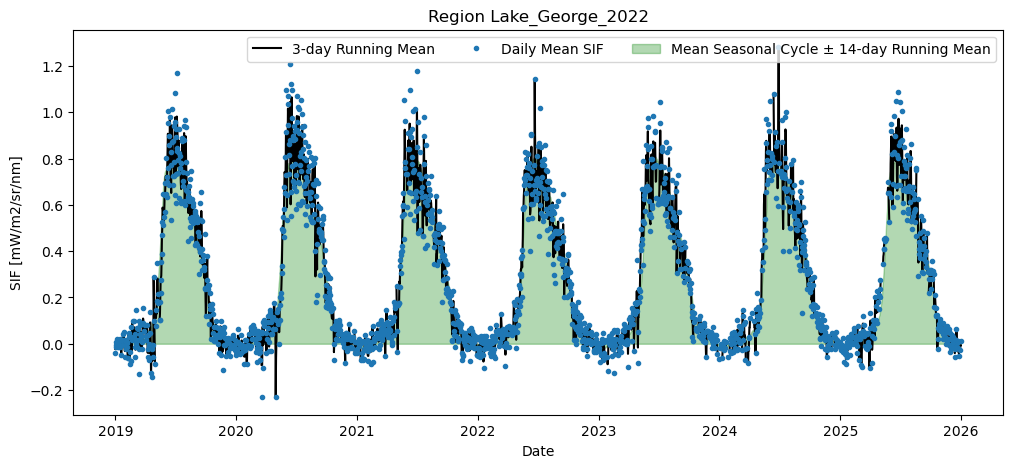

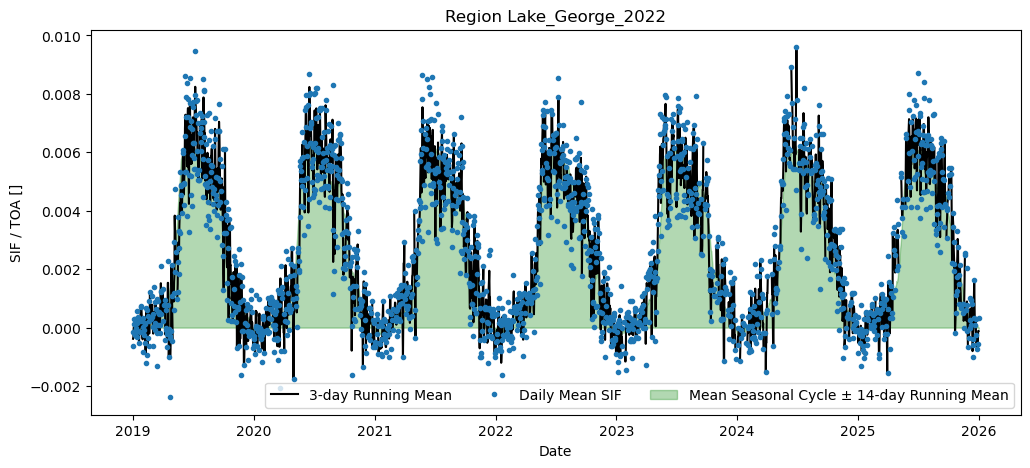

In [15]:
#3 day running mean
names = [RegionName, RegionName, RegionName]
vars = ["SIF_Corr_743", "SIF_Corr_743_TOAnorm", "EVI"]
for first, dic in enumerate([df1a, df1aWTOA]):#, dfEVI]):
    fig, ax = plt.subplots(figsize= (12,5))
    dic.sort_values("Date", inplace = True)
    ax.plot(dic.Date, dic[f"{vars[first]}_3RunningMean"], marker = '', ls = "-", color = 'black', label = '3-day Running Mean')
    ax.plot(dic.Date, dic[vars[first]], marker = '.', ls = "", label = 'Daily Mean SIF')
    ax.fill_between(dic.Date, dic[f"MSC_{vars[first]}_14RunningMean"], ls = "-", color='green', alpha=0.3, label='Mean Seasonal Cycle ± 14-day Running Mean')
    if first == 0:
        ax.set_ylabel("SIF [mW/m2/sr/nm]")
    elif first == 1:
        ax.set_ylabel("SIF / TOA []")
    else:
        ax.set_ylabel("EVI []")

    ax.legend(ncol=3)
    ax.set_xlabel("Date")
    ax.set_title(f"Region {names[first]}")


14-day mean with percentages

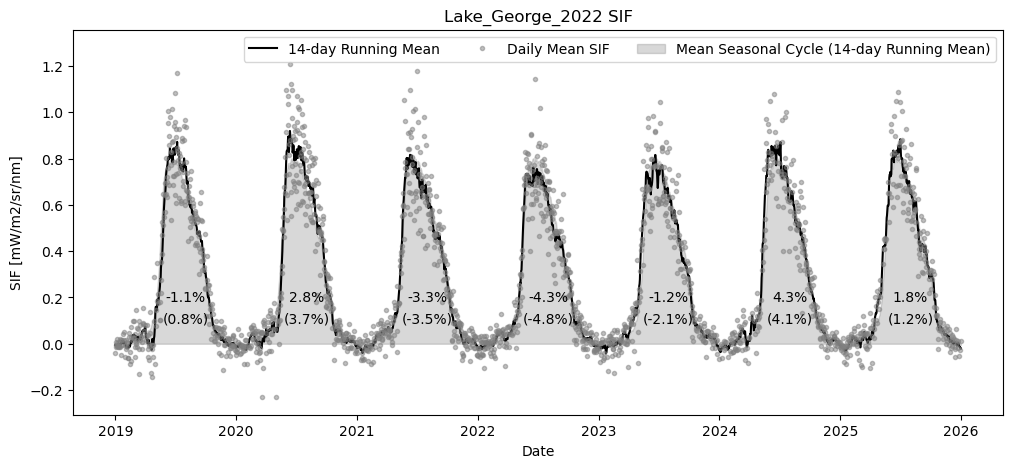

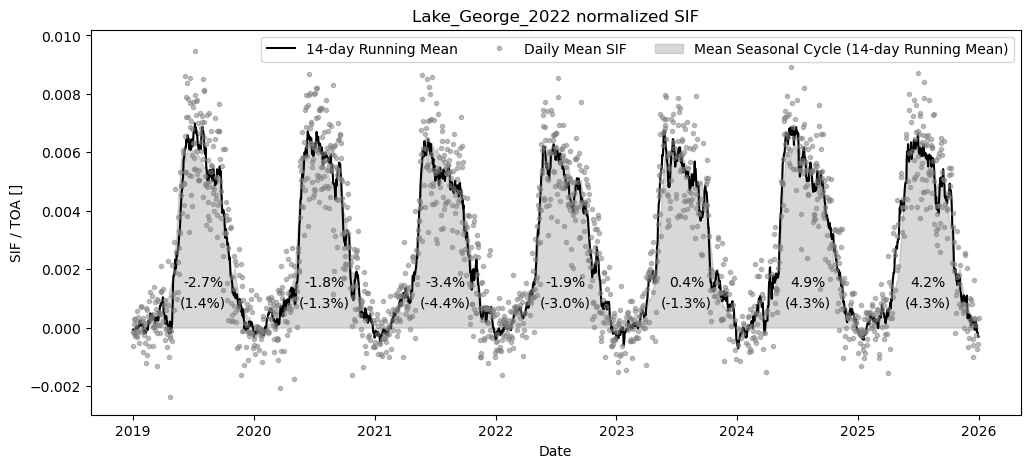

In [16]:
names = [RegionName + " SIF",RegionName + " normalized SIF",RegionName + " EVI",RegionName + " EVI subtracted baseline"]
vars = ["SIF_Corr_743", "SIF_Corr_743_TOAnorm"]#, "EVI", "EVI_subOffset"]
colors = [["black","grey","grey"],["black","grey","grey"],["darkgreen","green","green"],["darkgreen","green","green"]]

for first, dic in enumerate([df1a, df1aWTOA]):#, dfEVI, dfEVI]):
    
    fig, ax = plt.subplots(figsize= (12,5))
    dic.sort_values("Date", inplace = True)
    ax.plot(dic.Date, dic[f"{vars[first]}_14RunningMean"], marker = '', ls = "-", color = colors[first][0], label = '14-day Running Mean')
    if first < 3:
        ax.plot(dic.Date, dic[vars[first]], marker = '.', ls = "", color = colors[first][1],label = 'Daily Mean '+vars[first].split("_")[0], alpha = 0.5)
        ax.fill_between(dic.Date, dic[f"MSC_{vars[first]}_14RunningMean"], ls = "-", color=colors[first][2], alpha=0.3, label='Mean Seasonal Cycle (14-day Running Mean)')
    else:
        ax.plot(dic.Date, dic[vars[first]], marker = '.', ls = "", color = colors[first][1],label = 'Daily Mean '+vars[first].split("_")[0], alpha = 0.5)
        ax.fill_between(dic.Date, dic[f"MSC_{vars[first]}_14RunningMean"].min(), dic[f"MSC_{vars[first]}_14RunningMean"], ls = "-", color=colors[first][2], alpha=0.3, label='Mean Seasonal Cycle (14-day Running Mean)')
    
    if first == 0:
        ax.set_ylabel("SIF [mW/m2/sr/nm]")
    elif first == 1:
        ax.set_ylabel("SIF / TOA []")
    else:
        ax.set_ylabel("EVI")
    #add diffPerc in each year in the middle of the year in each year
    for year in df1ayear.index:
        if first == 0:
            ax.text(datetime.date(year, 8, 1), dic[f"{vars[first]}_14RunningMean"].max()*0.2, f"{df1ayear.loc[year,'diffPerc']:.1f}%", color='black', fontsize=10, ha='center')
            ax.text(datetime.date(year, 8, 1), dic[f"{vars[first]}_14RunningMean"].max()*0.1, f"({df1ayearMai2Oct.loc[year,'diffPerc']:.1f}%)", color='black', fontsize=10, ha='center')

        elif first == 1:
            ax.text(datetime.date(year, 8, 1), dic[f"{vars[first]}_14RunningMean"].max()*0.2, f"{df1aWTOAyear.loc[year,'diffPerc']:.1f}%", color='black', fontsize=10, ha='center')
            ax.text(datetime.date(year, 8, 1), dic[f"{vars[first]}_14RunningMean"].max()*0.1, f"({df1aWTOAyearMai2Oct.loc[year,'diffPerc']:.1f}%)", color='black', fontsize=10, ha='center')

        elif first == 2:
            ax.text(datetime.date(year, 8, 1), dic[f"{vars[first]}_14RunningMean"].max()*0.2, f"{dfEVIyear.loc[year,'diffPerc']:.1f}%", color='darkgreen', fontsize=10, ha='center')
            ax.text(datetime.date(year, 8, 1), dic[f"{vars[first]}_14RunningMean"].max()*0.1, f"({dfEVIyearMai2Oct.loc[year,'diffPerc']:.1f}%)", color='darkgreen', fontsize=10, ha='center')

        else:
            ax.text(datetime.date(year, 8, 1), dic[f"{vars[first]}_14RunningMean"].max()*0.2, f"{dfEVIyear.loc[year,'diffPerc_subOffset']:.1f}%", color='darkgreen', fontsize=10, ha='center')
            ax.text(datetime.date(year, 8, 1), dic[f"{vars[first]}_14RunningMean"].max()*0.1, f"({dfEVIyearMai2Oct.loc[year,'diffPerc_subOffset']:.1f}%)", color='darkgreen', fontsize=10, ha='center')


    ax.legend(ncol=3)
    ax.set_xlabel("Date")
    ax.set_title(f"{names[first]}")
    fig.savefig(f"/home/evametz/plots/SIF_Defoliage/US/{names[first].replace(' ','_')}_timeseries_wAnnualReduction.png", dpi=300, bbox_inches='tight')
    #save as pdf
    fig.savefig(f"/home/evametz/plots/SIF_Defoliage/US/{names[first].replace(' ','_')}_timeseries_wAnnualReduction.pdf", dpi=300, bbox_inches='tight')


7 day mean

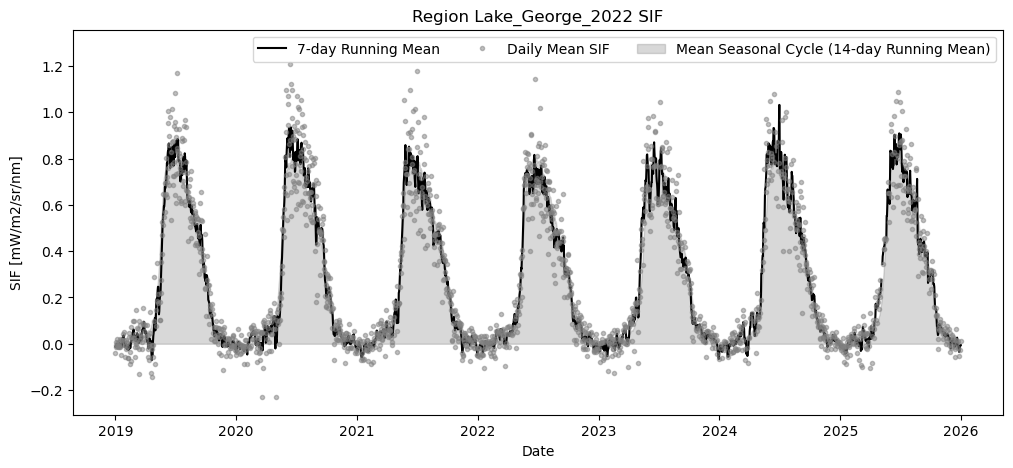

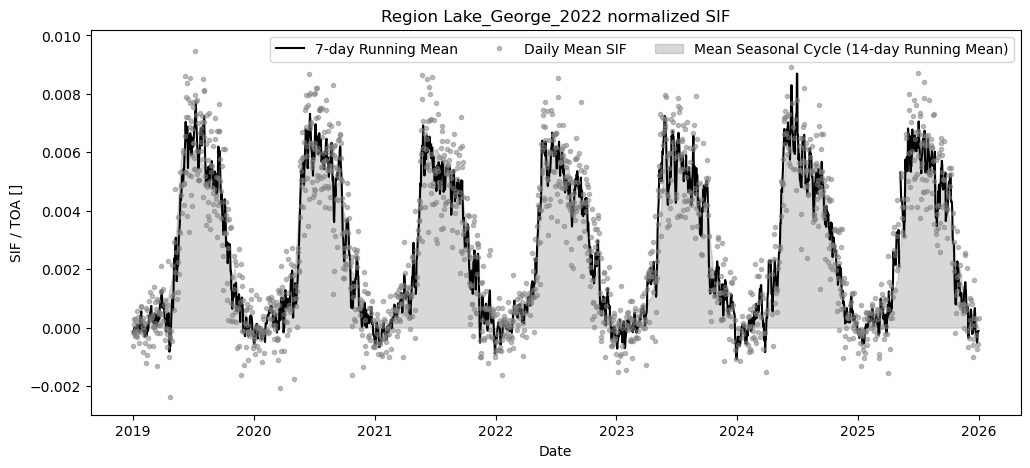

In [17]:
names = [RegionName + " SIF",RegionName + " normalized SIF",RegionName + " EVI"]
vars = ["SIF_Corr_743", "SIF_Corr_743_TOAnorm"]#, "EVI"]
colors = [["black","grey","grey"],["black","grey","grey"],["darkgreen","green","green"]]
for first, dic in enumerate([df1a, df1aWTOA]):#, dfEVI]):
    
    fig, ax = plt.subplots(figsize= (12,5))
    dic.sort_values("Date", inplace = True)
    ax.plot(dic.Date, dic[f"{vars[first]}_7RunningMean"], marker = '', ls = "-", color = colors[first][0], label = '7-day Running Mean')
    ax.plot(dic.Date, dic[vars[first]], marker = '.', ls = "", color = colors[first][1],label = 'Daily Mean '+vars[first].split("_")[0], alpha = 0.5)
    ax.fill_between(dic.Date, dic[f"MSC_{vars[first]}_14RunningMean"], ls = "-", color=colors[first][2], alpha=0.3, label='Mean Seasonal Cycle (14-day Running Mean)')
    if first == 0:
        ax.set_ylabel("SIF [mW/m2/sr/nm]")
    elif first == 1:
        ax.set_ylabel("SIF / TOA []")
    else:
        ax.set_ylabel("EVI []")

    ax.legend(ncol=3)
    ax.set_xlabel("Date")
    ax.set_title(f"Region {names[first]}")
